In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Download necessary NLP resources
nltk.download('stopwords')

# Load the dataset (Use a smaller subset like 50k rows to start)
df = pd.read_csv('Reviews.csv')

# Create a binary 'Sentiment' column: 4-5 stars = 1 (Positive), 1-2 stars = 0 (Negative)
# We ignore 3-star reviews to keep the sentiment clear
df = df[df['Score'] != 3]
df['Sentiment'] = df['Score'].apply(lambda x: 1 if x > 3 else 0)

print(df['Sentiment'].value_counts())
df[['Text', 'Sentiment']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Sentiment
1    443777
0     82037
Name: count, dtype: int64


,Text,Sentiment
0,I have bought several of the Vitality canned d...,1
1,Product arrived labeled as Jumbo Salted Peanut...,0
2,This is a confection that has been around a fe...,1
3,If you are looking for the secret ingredient i...,0
4,Great taffy at a great price. There was a wid...,1


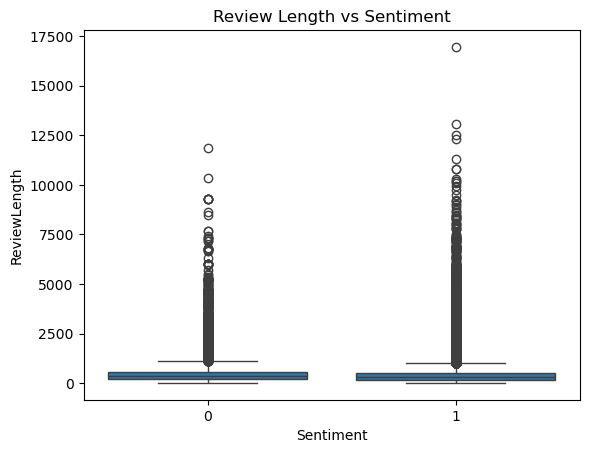

In [2]:
df['ReviewLength'] = df['Text'].apply(len)
sns.boxplot(x='Sentiment', y='ReviewLength', data=df)
plt.title('Review Length vs Sentiment')
plt.show()

In [3]:
import re

def clean_text(text):
    # Remove HTML tags, special characters, and numbers
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower().split()
    
    # Remove stop words
    stop_words = set(stopwords.words('english'))
    text = [w for w in text if not w in stop_words]
    
    return " ".join(text)

# Apply cleaning (This might take a minute)
df['CleanText'] = df['Text'].apply(clean_text)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialize the Vectorizer
# max_features=5000 means we only keep the 5,000 most important words
# ngram_range=(1,2) allows the model to see both single words ("good") and pairs ("not good")
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# 2. Transform the text into numbers
X = tfidf.fit_transform(df['CleanText'])
y = df['Sentiment']

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Vectorization complete. Input shape: {X_train.shape}")

Vectorization complete. Input shape: (420651, 5000)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1. Train the model
lr_sentiment = LogisticRegression(max_iter=1000)
lr_sentiment.fit(X_train, y_train)

# 2. Evaluate
y_pred = lr_sentiment.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.9334
              precision    recall  f1-score   support

           0       0.85      0.70      0.77     16379
           1       0.95      0.98      0.96     88784

    accuracy                           0.93    105163
   macro avg       0.90      0.84      0.86    105163
weighted avg       0.93      0.93      0.93    105163



In [7]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = lr_sentiment.predict(vectorized)[0]
    prob = lr_sentiment.predict_proba(vectorized)[0]
    
    sentiment = "Positive" if prediction == 1 else "Negative"
    print(f"Text: {text}\nResult: {sentiment} (Confidence: {max(prob):.2%})\n")

# Try these!
predict_sentiment("The packaging was beautiful but the taste was absolutely metallic and gross.")
predict_sentiment("I was skeptical at first, but this is now a staple in my kitchen.")

Text: The packaging was beautiful but the taste was absolutely metallic and gross.
Result: Negative (Confidence: 78.58%)

Text: I was skeptical at first, but this is now a staple in my kitchen.
Result: Positive (Confidence: 99.75%)



In [10]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
    --------------------------------------- 5.2/351.2 MB 26.5 MB/s eta 0:00:14
   - -------------------------------------- 11.0/351.2 MB 26.5 MB/s eta 0:00:13
   -- ------------------------------------- 17.8/351.2 MB 27.9 MB/s eta 0:00:12
   -- ------------------------------------- 22.3/351.2 MB 28.5 MB/s eta 0:00:12
   --- ------------------------------------ 26.5/351.2 MB 24.7 MB/s eta 0:00:14
   --- ------------------------------------ 31.5/351.2 MB 24.5 MB/s eta 0:00:14
   ---- ----------------------------------- 36.2/351.2 MB 24.1 MB/s eta 0:00:14
   ---- ----------------------------------- 41.2/351.2 MB 24.2 MB/s eta 0:00:13
   ----- ---------------------------------- 46.4/351.2 MB 24.2 MB/s eta 0:00:13
   ----- ---------------------------------- 51.4/351.2 MB 24.1 MB/s eta 0:00:13
   ------ --------------------------------- 56.6/351.2 MB 24.0 MB/s eta 0:00:13
   ------- -------------------------------- 61.6/3

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# 1. Tokenization & Sequence Preparation
max_words = 10000  # Only keep the top 10k most frequent words
max_len = 100     # Truncate/Pad reviews to 100 words
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['CleanText'])

sequences = tokenizer.texts_to_sequences(df['CleanText'])
X_seq = pad_sequences(sequences, maxlen=max_len)

# 2. Train-Test Split (Sequence data)
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_seq, y, test_size=0.2, random_state=42)

# 3. Build the LSTM Architecture
model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2), # Dropout prevents overfitting
    Dense(1, activation='sigmoid') # Binary output: Positive/Negative
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 4. Training (This will take time - adjust epochs based on your CPU/GPU)
history = model.fit(X_train_dl, y_train_dl, epochs=3, batch_size=64, validation_split=0.1)

C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
5916/5916 ━━━━━━━━━━━━━━━━━━━━ 646s 108ms/step - accuracy: 0.9279 - loss: 0.1870 - val_accuracy: 0.9416 - val_loss: 0.1538
Epoch 2/3
5916/5916 ━━━━━━━━━━━━━━━━━━━━ 625s 106ms/step - accuracy: 0.9483 - loss: 0.1378 - val_accuracy: 0.9462 - val_loss: 0.1444
Epoch 3/3
5916/5916 ━━━━━━━━━━━━━━━━━━━━ 637s 108ms/step - accuracy: 0.9577 - loss: 0.1146 - val_accuracy: 0.9488 - val_loss: 0.1407


In [14]:
!pip install transformers

   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   -------------------------- ------------- 7.1/10.6 MB 34.9 MB/s eta 0:00:01
   ---------------------------------------- 10.6/10.6 MB 33.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/661.5 kB ? eta -:--:--
   --------------------------------------- 661.5/661.5 kB 22.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 4.0/4.0 MB 26.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 24.9 MB/s eta 0:00:00

  Attempting uninstall: regex

    Found existing installation: regex 2024.11.6

    Uninstalling regex-2024.11.6:

      Successfully uninstalled regex-2024.11.6

   ---- ----------------------------------- 1/9 [regex]
   -------- ------------------------------- 2/9 [hf-xet]
  Attempting uninstall: click
   -------- ----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [16]:
%pip install torch torchvision

   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   -- ------------------------------------- 6.3/114.6 MB 33.8 MB/s eta 0:00:04
   ---- ----------------------------------- 13.9/114.6 MB 35.3 MB/s eta 0:00:03
   ------ --------------------------------- 17.6/114.6 MB 30.0 MB/s eta 0:00:04
   ------- -------------------------------- 21.5/114.6 MB 26.4 MB/s eta 0:00:04
   --------- ------------------------------ 26.7/114.6 MB 26.9 MB/s eta 0:00:04
   ----------- ---------------------------- 31.7/114.6 MB 25.4 MB/s eta 0:00:04
   ------------ --------------------------- 36.7/114.6 MB 25.4 MB/s eta 0:00:04
   -------------- ------------------------- 41.7/114.6 MB 25.2 MB/s eta 0:00:03
   ---------------- ----------------------- 46.9/114.6 MB 25.3 MB/s eta 0:00:03
   ------------------ --------------------- 51.9/114.6 MB 25.2 MB/s eta 0:00:03
   -------------------- ------------------- 57.7/114.6 MB 25.4 MB/s eta 0:00:03
   ---------------------- ----------------- 63.7/1

In [4]:
import torch
import transformers
print(f"Torch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")

Torch version: 2.11.0+cpu
Transformers version: 5.8.0


In [5]:
import torch # Crucial for the BERT models to function
from transformers import pipeline

# 1. Initialize the BERT pipeline
# This uses a version of BERT optimized for sentiment analysis
bert_analyzer = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# 2. Define complex test cases to see the difference between models
test_samples = [
    "The product isn't as bad as people say, but it's not great either.", # Nuance
    "I thought I would hate this, but I actually love it.",             # Contrast
    "If you like wasting money, this is the perfect product for you."     # Sarcasm
]

# 3. Get BERT results
print("--- BERT Predictions ---")
for sample in test_samples:
    result = bert_analyzer(sample)[0]
    print(f"Text: {sample}\nResult: {result['label']} (Confidence: {result['score']:.2%})\n")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

--- BERT Predictions ---
Text: The product isn't as bad as people say, but it's not great either.
Result: NEGATIVE (Confidence: 99.90%)

Text: I thought I would hate this, but I actually love it.
Result: POSITIVE (Confidence: 99.98%)

Text: If you like wasting money, this is the perfect product for you.
Result: POSITIVE (Confidence: 99.86%)



In [6]:
results_data = {
    "Model": ["Logistic Regression", "LSTM", "BERT (DistilBERT)"],
    "Accuracy": [0.9334, 0.9488, "N/A (Pre-trained)"],
    "Strengths": ["Speed, Transparency", "Sequence Memory", "Nuance & Context"],
    "Weaknesses": ["Fails at Negation", "Compute Intensive", "Sarcasm Blindness"]
}

comparison_df = pd.DataFrame(results_data)
print(comparison_df)

                 Model           Accuracy            Strengths  \
0  Logistic Regression             0.9334  Speed, Transparency   
1                 LSTM             0.9488      Sequence Memory   
2    BERT (DistilBERT)  N/A (Pre-trained)     Nuance & Context   

          Weaknesses  
0  Fails at Negation  
1  Compute Intensive  
2  Sarcasm Blindness  
